Kent Lin Chan

20202132

Se usó python 3.14.2


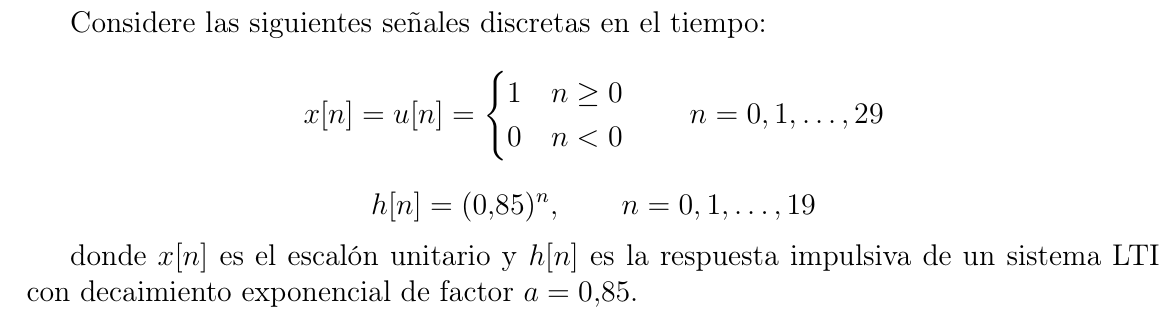

Importar librerías

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from math import *
np.__version__

n=np.linspace(0,29,30)
print(n)
u=np.heaviside(n,1)

print(u, u.size)

n2=np.linspace(0,19,20)
print(n2)
h=(0.85)**n2

print(h, h.size)

[ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17.
 18. 19. 20. 21. 22. 23. 24. 25. 26. 27. 28. 29.]
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1.] 30
[ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17.
 18. 19.]
[1.         0.85       0.7225     0.614125   0.52200625 0.44370531
 0.37714952 0.32057709 0.27249053 0.23161695 0.1968744  0.16734324
 0.14224176 0.12090549 0.10276967 0.08735422 0.07425109 0.06311342
 0.05364641 0.04559945] 20


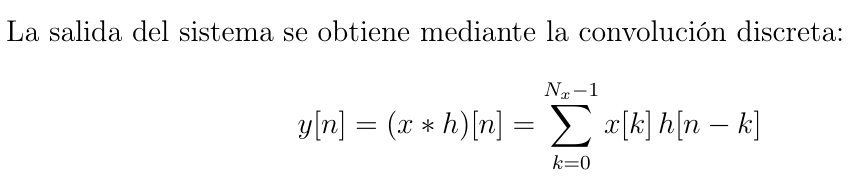

(a) Implemente en Python la función my_convolve(x, h) que calcule la convolución
discreta de forma manual sin utilizar la función np.convolve.

In [2]:
def my_convolve(x,h):
    #Crear un arreglo de tamaño de ceros donde se guarda los datos, el valor es el tamaño de x + el tamaño de h - 1
    y=np.zeros(x.size+h.size-1)
    #Recorrer el bucle para cada posición de y
    for i in range(y.size):
        #Recorrer el bucle para cada posición de x
        for j in range(x.size):
            #Validar que los valores de i-j estén dentro del rango de h
            if i-j>=0 and i-j<h.size:
                #Sumar el producto de x[j] y h[i-j] a y[i]
                y[i]+=x[j]*h[i-j]
    return y

In [3]:
#Realizar la convolución de u y h utilizando la función my_convolve
y1=my_convolve(u,h)

print(y1, y1.size)

[1.         1.85       2.5725     3.186625   3.70863125 4.15233656
 4.52948608 4.85006317 5.12255369 5.35417064 5.55104504 5.71838829
 5.86063004 5.98153554 6.08430521 6.17165943 6.24591051 6.30902393
 6.36267034 6.40826979 6.40826979 6.40826979 6.40826979 6.40826979
 6.40826979 6.40826979 6.40826979 6.40826979 6.40826979 6.40826979
 5.40826979 4.55826979 3.83576979 3.22164479 2.69963854 2.25593323
 1.87878371 1.55820663 1.2857161  1.05409916 0.85722475 0.68988151
 0.54763975 0.42673426 0.32396459 0.23661037 0.16235928 0.09924586
 0.04559945] 49


(b) Calcule la misma convolución usando np.convolve con mode=’full’ y compare los
resultados con su implementación manual. Comente sus resultados.

In [4]:
#Realizar la convolución de u y h utilizando la función convolve de numpy
y2=np.convolve(u,h,mode='full')
print(y2, y2.size)

[1.         1.85       2.5725     3.186625   3.70863125 4.15233656
 4.52948608 4.85006317 5.12255369 5.35417064 5.55104504 5.71838829
 5.86063004 5.98153554 6.08430521 6.17165943 6.24591051 6.30902393
 6.36267034 6.40826979 6.40826979 6.40826979 6.40826979 6.40826979
 6.40826979 6.40826979 6.40826979 6.40826979 6.40826979 6.40826979
 5.40826979 4.55826979 3.83576979 3.22164479 2.69963854 2.25593323
 1.87878371 1.55820663 1.2857161  1.05409916 0.85722475 0.68988151
 0.54763975 0.42673426 0.32396459 0.23661037 0.16235928 0.09924586
 0.04559945] 49


(c) Grafique las siguientes señales usando stem en subgráficas separadas:

Señal de entrada x[n]

Respuesta impulsiva h[n]

Salida y[n] obtenida con my_convolve

Comparación superpuesta: my_convolve vs np.convolve


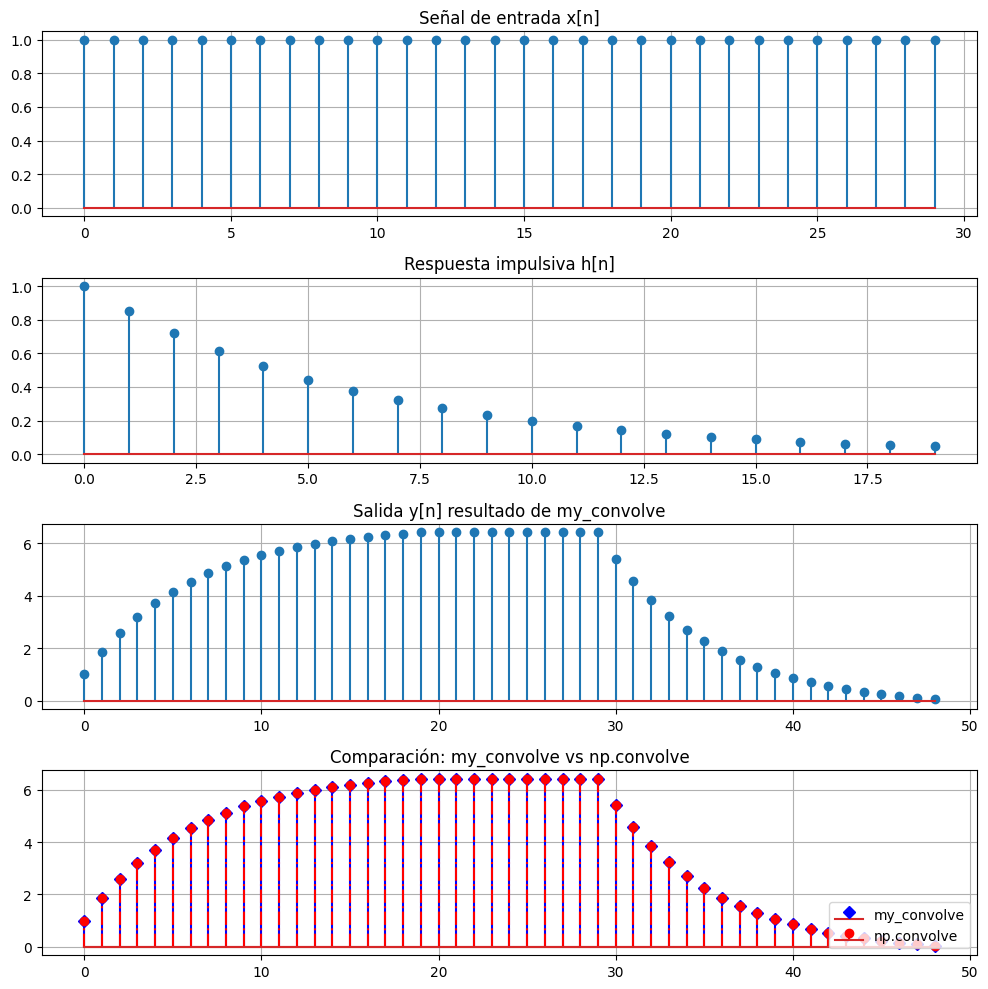

In [5]:
plt.figure(figsize=(10, 10))

# Señal de entrada x[n] (nombrada u en el código)
plt.subplot(4, 1, 1)
plt.stem(u)
plt.title('Señal de entrada x[n]')
plt.grid(True)

# Respuesta impulsiva h[n]
plt.subplot(4, 1, 2)
plt.stem(h)
plt.title('Respuesta impulsiva h[n]')
plt.grid(True)

# Salida y[n] resultado de my_convolve
plt.subplot(4, 1, 3)
plt.stem(y1)
plt.title('Salida y[n] resultado de my_convolve')
plt.grid(True)

# Comparación superpuesta: my_convolve vs np.convolve
plt.subplot(4, 1, 4)
plt.stem(range(len(y1)), y1, linefmt='b-', markerfmt='bD', label='my_convolve')
plt.stem(range(len(y2)), y2, linefmt='r-.', markerfmt='ro', label='np.convolve')
plt.title('Comparación: my_convolve vs np.convolve')
plt.legend()
plt.grid(True)
plt.legend(loc='lower right')

plt.tight_layout()

plt.show()